In [1]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
import pickle

from utilities import single_px_retrieval

# %matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [123]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the three classes:
# white tarp, black tarp, aspen

# update from 8/4:
# same isofit config, just run for all 4 cal flightlines and compare retrievals

In [2]:
# define file paths
home = '/store/carroll/col/2018/'
aspen = home+'test_roi/aspen/'
cal = home+'test_roi/calTarp/'

extra_data = '/store/carroll/col/'

dir_insitu = home+'insitu/'

fp_single_px = '/store/carroll/col/2018/test_roi/single_pxs.pkl'

wl = np.loadtxt('/store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt')[:,1]*1000
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

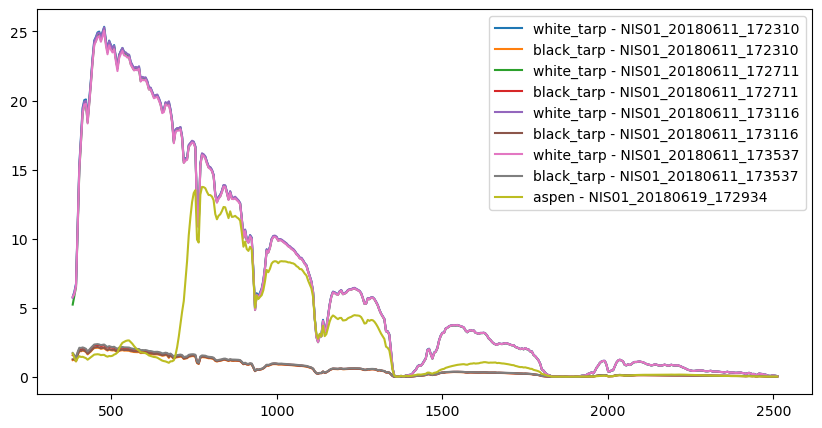

In [3]:
# load, viz representative px

with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)
rdn = single_px['rdn']
obs = single_px['obs']
loc = single_px['loc']
bboxes = single_px['bboxes']

flights = list(rdn.keys())

fig = plt.figure(figsize=(10,5))
for f in rdn.keys():
    for k in rdn[f].keys():
        plt.plot(wl, rdn[f][k], label=f'{k} - {f}')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_172310 white_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

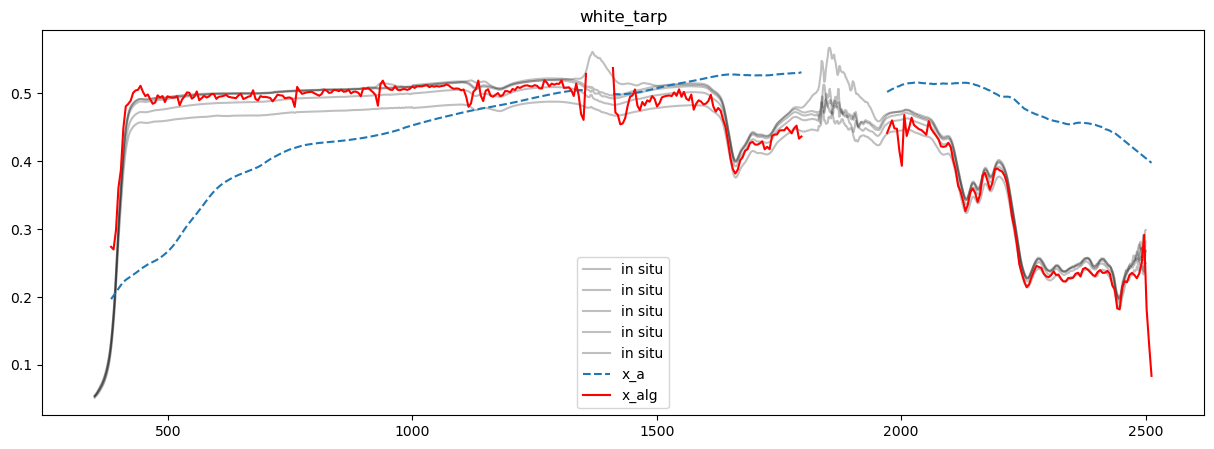

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_172310 black_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

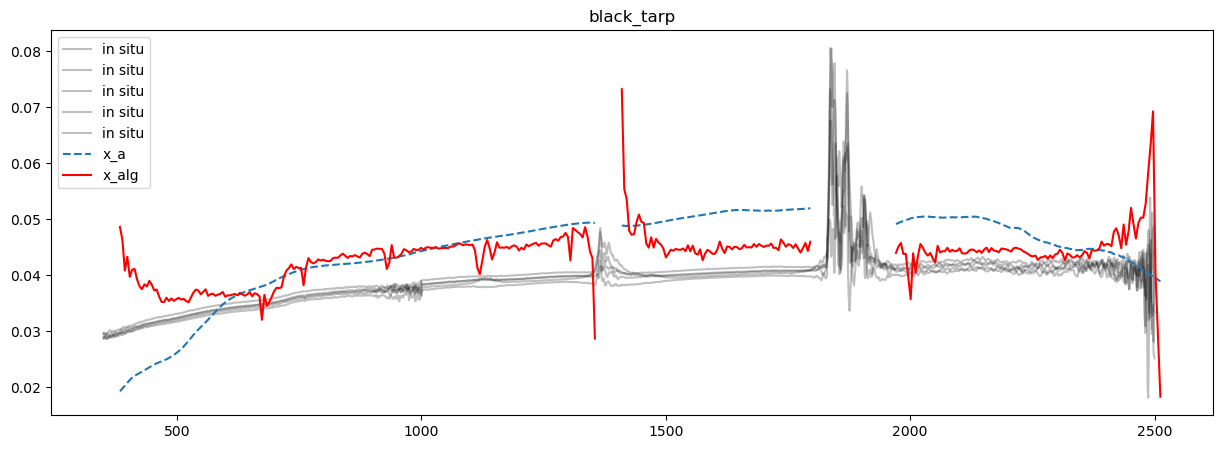

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172711_sRTMnet_20250806/config/NIS01_20180611_172711_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172711_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_172711 white_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 7442 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 observer_zenith(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'observer_zenith': None} ;
}

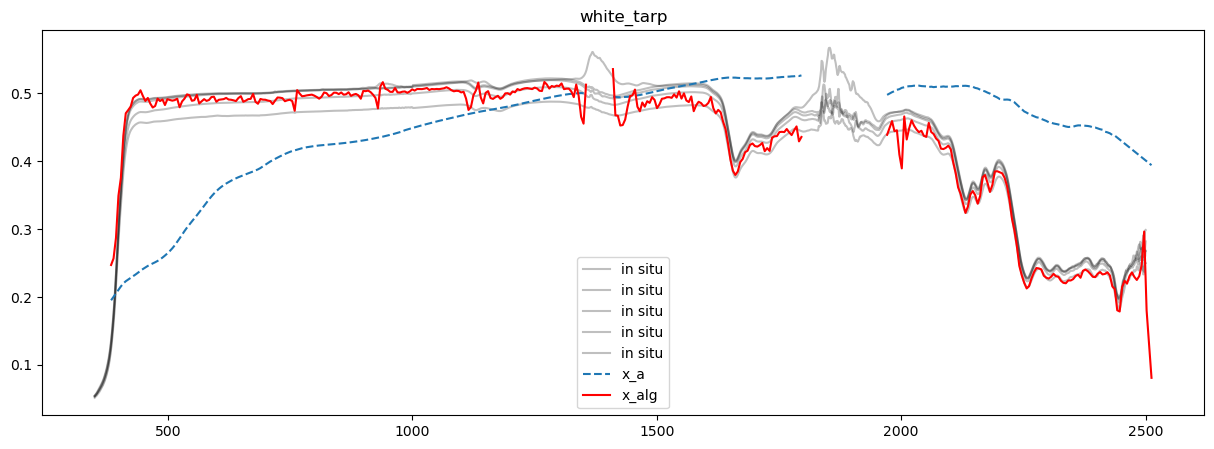

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172711_sRTMnet_20250806/config/NIS01_20180611_172711_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172711_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_172711 black_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 7442 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 observer_zenith(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'observer_zenith': None} ;
}

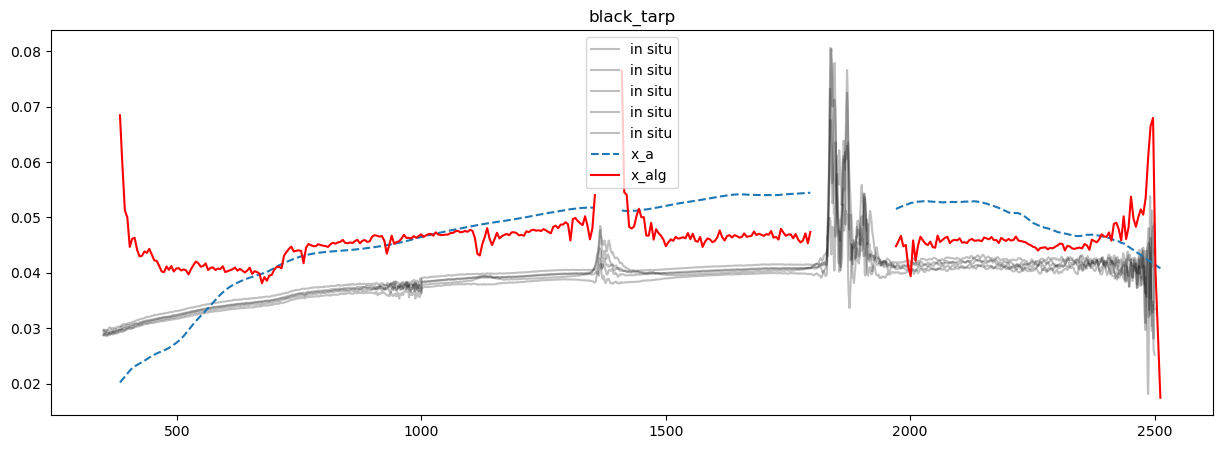

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173116_sRTMnet_20250806/config/NIS01_20180611_173116_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173116_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_173116 white_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 7442 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 relative_azimuth(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'relative_azimuth': None} ;
}

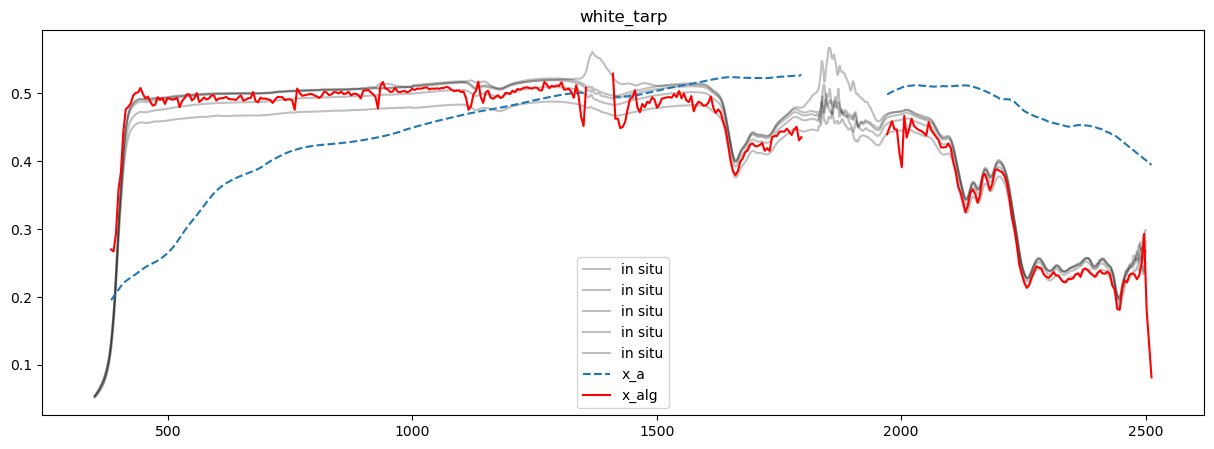

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173116_sRTMnet_20250806/config/NIS01_20180611_173116_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173116_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_173116 black_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 7442 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 relative_azimuth(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'relative_azimuth': None} ;
}

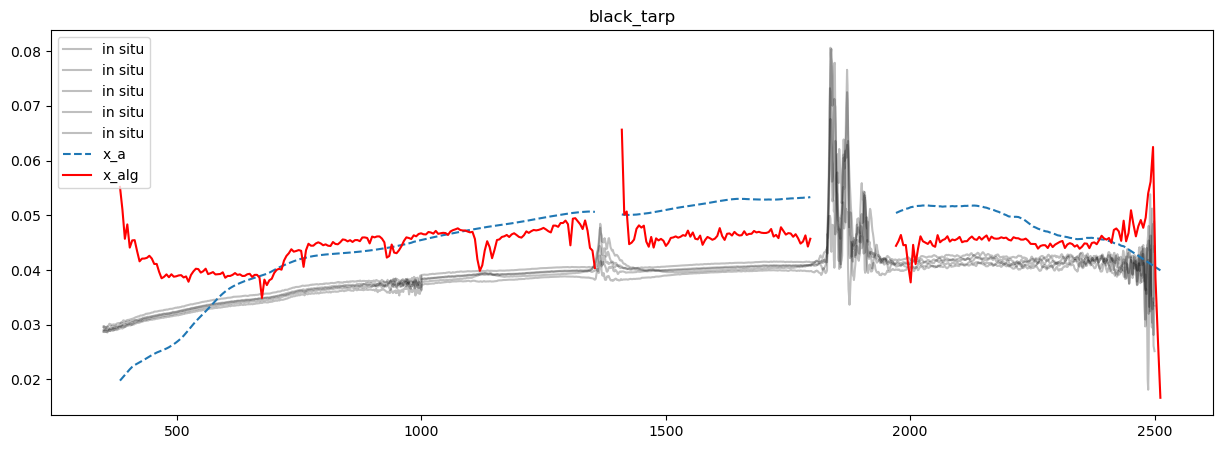

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173537_sRTMnet_20250806/config/NIS01_20180611_173537_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173537_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_173537 white_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 7442 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 observer_zenith(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'observer_zenith': None} ;
}

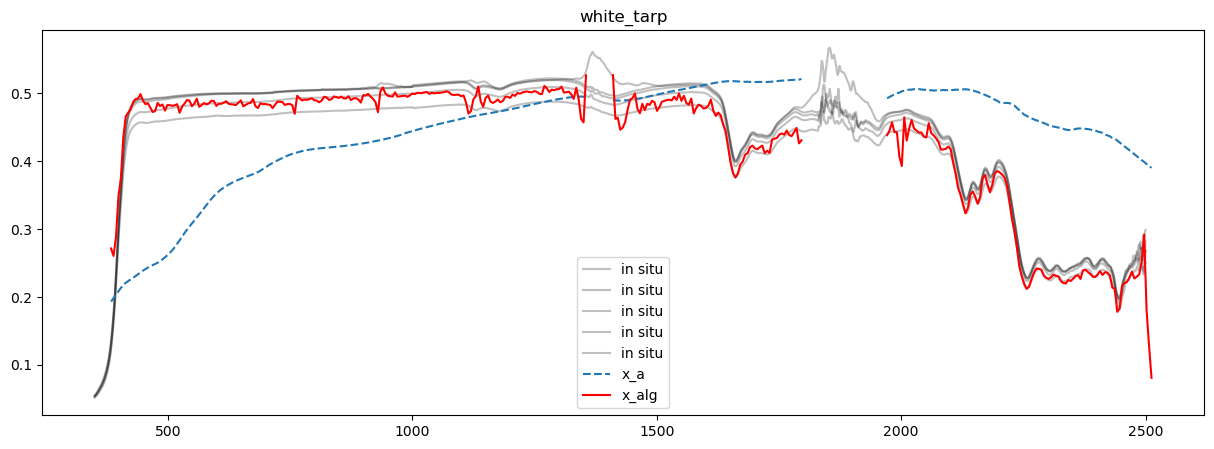

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173537_sRTMnet_20250806/config/NIS01_20180611_173537_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_173537_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_173537 black_tarp


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 7442 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 observer_zenith(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'observer_zenith': None} ;
}

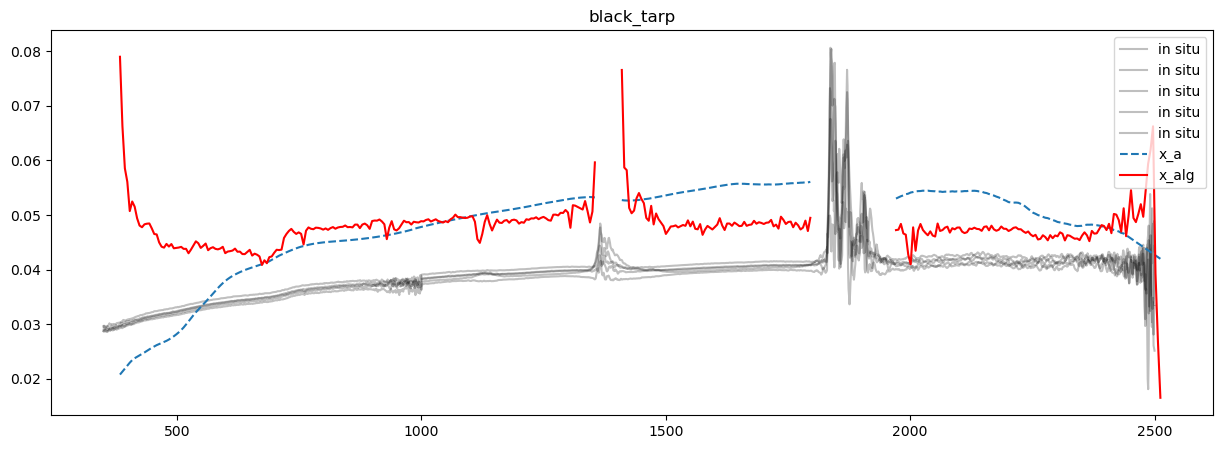

Error for flight NIS01_20180619_172934, key white_tarp: list index out of range
Error for flight NIS01_20180619_172934, key black_tarp: list index out of range


In [4]:
# loop through all flightlines for cal tarps

# set up dict to hold outputs 
x_algs = {k: {} for k in rdn.keys()}
rccs = {k: {} for k in rdn.keys()}

# define global parameters
version = '20250806'
fol = cal
fp_surface = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat')
fp_noise = extra_data + 'avirisng_noise_neon.txt'
integrations = 2
fp_channelized_radiometric_uncertaint = extra_data + 'avirisng_systematic_error_neon.txt'
fp_model_discrepancy = extra_data + 'avirisng_model_discrepancy_neon.mat'

for flight in flights:
    for k in ['white_tarp', 'black_tarp']:
        
        try:
            # load, update config file
            fp_config = glob(os.path.join(fol, f'{flight}*{version}', 'config', '*_isofit.json'))[0]
            config = configs.create_new_config(fp_config)
            config.forward_model.surface.surface_file = fp_surface
            config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', f'{flight}_rdn'))[0]
            config.input.obs_file = glob(os.path.join(fol, 'subset', f'{flight}_obs'))[0]
            config.input.loc_file = glob(os.path.join(fol, 'subset', f'{flight}_igm'))[0]
            
            # borrow the avirisng instrument model, updated to neon wavelengths?
            config.forward_model.instrument.parametric_noise_file = fp_noise
            config.forward_model.instrument.integrations = integrations 
            config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = fp_channelized_radiometric_uncertaint
            config.forward_model.model_discrepancy_file = fp_model_discrepancy

            # set up to automatically derive rcc factors (this isn't working right now? not sure why, derive manually)
            fp_rfl = home + f'/insitu/cal_{k}_neon.txt'
            # fp_rcc_out = os.path.join(fol, f'{flight}_sRTMnet_{version}', 'output', f'rcc_{k}')
            # config.input.reference_reflectance_file = fp_rfl
            # config.output.radiometry_correction_file = fp_rcc_out
            
            print('\n', flight, k)
            
            # set up forward model, io, inv according to config
            fm = ForwardModel(config) # loads pre-built LUT
            io = IO(config, fm)
            inv = Inversion(config, fm)
            
            # load the isofit geometry representation of the single pixel
            rdn_ = rdn[flight][k]
            obs_ = obs[flight][k]
            loc_ = loc[flight][k]
            geom = Geometry(obs=obs_, loc=loc_)
            
            # run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and observed rdn
            states=inv.invert(rdn_, geom)
            x = states[-1,:]
            x_surface, x_RT, x_instrument = fm.unpack(x)
    
            # do a final algebraic inversion with the above solutions
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                                 x_surface, x_RT, x_instrument,
                                                 rdn_, geom)
            # get surface prior mean
            x0 = states[0,...][fm.idx_surface].copy()
            xa_full = fm.xa(x0, geom)
            xa = xa_full[fm.idx_surface]
    
            # get single px rcc
            insitu_rfl = np.loadtxt(fp_rfl)[:,1]
            modeled_rdn = fm.calc_meas(x, geom, insitu_rfl)
            rcc_ = modeled_rdn/rdn_
            
            # final rfl solution w/ in situ
            if k=='white_tarp':
                fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat'))
            else: fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
            fig = plt.figure(figsize=(15,5))
            for fp in fps:
                in_situ = np.genfromtxt(fp, skip_header=3)
                plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
            plt.plot(wl_nan, xa, label='x_a', ls='--')
            plt.plot(wl_nan, x_alg, label='x_alg', c='red')
            plt.title(f'{k}')
            plt.legend()
            plt.show()
            
            x_algs[flight][k] = x_alg
            rccs[flight][k] = rcc_
            
        except Exception as e:
            print(f"Error for flight {flight}, key {k}: {e}")

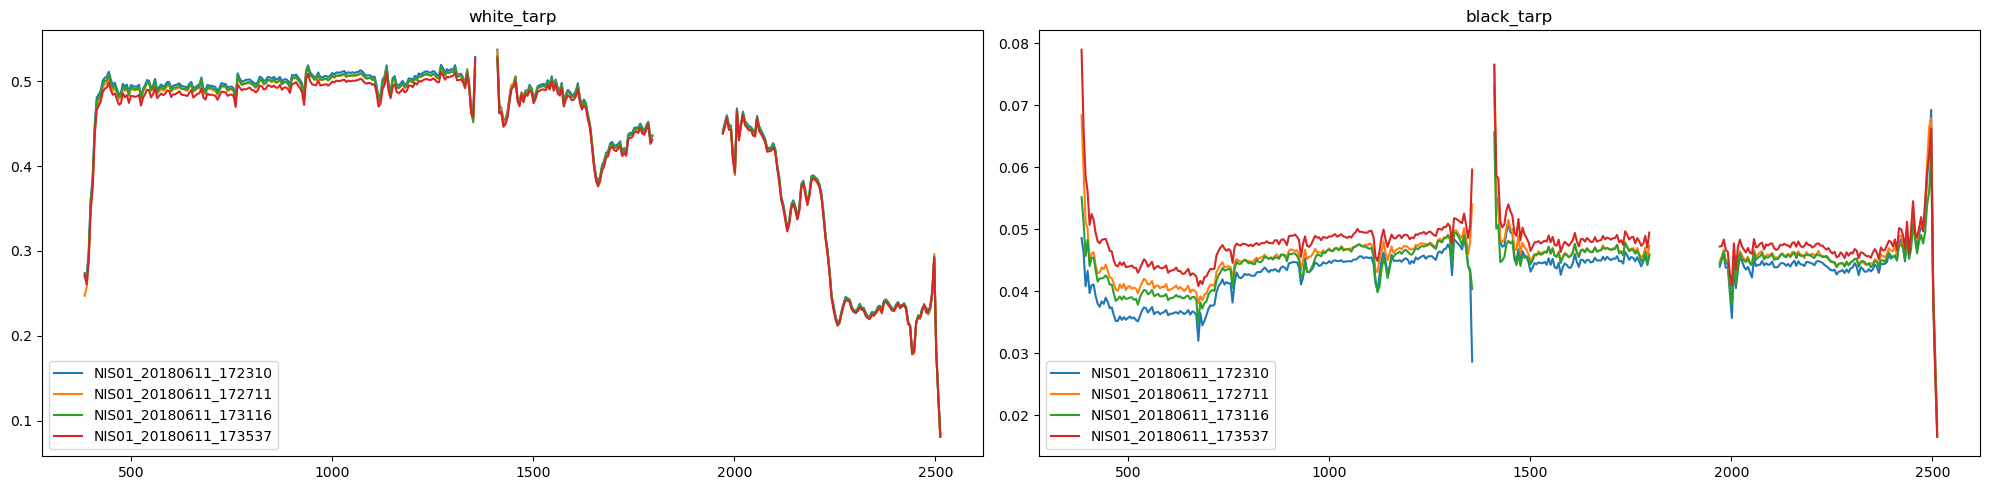

In [6]:
# look at the final algebraic surface solution from each flightline

fig, axs = plt.subplots(ncols=2, figsize=(20,5))

for flight in x_algs.keys():
    for k in x_algs[flight].keys():
        try:
            rfl_ = x_algs[flight][k]
            if k=='white_tarp':
                i=0
            else: i=1
            axs[i].plot(wl_nan, rfl_, label=flight)
            axs[i].set_title(k)
            axs[i].legend()
        except: pass
plt.tight_layout()
plt.show()